<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [40]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

Import pandas module


In [59]:
import pandas as pd


Import matplotlib


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [61]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [62]:
## Write your code here
duplicate_count = df.duplicated().sum()
duplicates = df[df.duplicated(keep=False)]

print(f"Number of duplicated rows: {duplicate_count}")
duplicates.head()

Number of duplicated rows: 20

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [63]:
# Calculating the RespondentCount for the same MainBranch, Employment and RemoteWork
pattern_cols = ["MainBranch","Employment","RemoteWork"]

response_patterns = (
    df.groupby(pattern_cols, dropna=False) # do not drop NaN values
      .size()
      .reset_index(name="RespondentCount")
      .sort_values("RespondentCount", ascending=False)
)

response_patterns.head(10)

,MainBranch,Employment,RemoteWork,RespondentCount
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
2,I am a developer by profession,"Employed, full-time",Remote,12196
1,I am a developer by profession,"Employed, full-time",In-person,7118
82,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
9,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754
244,I am learning to code,"Student, full-time",NaN,1543
280,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",1479
111,I am a developer by profession,"Not employed, but looking for work",NaN,1307
456,I code primarily as a hobby,"Student, full-time",NaN,1275
7,I am a developer by profession,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",1169


In [64]:
# Identifying the actual respondents to the pattern: 'I am a developer by profession', 'Employed, full-time', 'Hybrid (some remote, some in-person)' 
pattern = (
    df["MainBranch"].eq('I am a developer by profession') &
    df["Employment"].eq('Employed, full-time') &
    df["RemoteWork"].eq('Hybrid (some remote, some in-person)')
)

pattern_group = df.loc[pattern]
pattern_group[["ResponseId","MainBranch","Employment","RemoteWork","Country"]].sort_values(by="Country",ascending=False).head(10)

,ResponseId,MainBranch,Employment,RemoteWork,Country
20049,20050,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Zimbabwe
24334,24335,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Zimbabwe
31444,31445,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Zimbabwe
29622,29623,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Zambia
53682,53683,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Yemen
212,213,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Viet Nam
2692,2693,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Viet Nam
3381,3382,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Viet Nam
3404,3405,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Viet Nam
6912,6913,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",Viet Nam


**Conclusion:** The same group patterns appear accross different responses even for same countries. Users can have the same answers accross different attributes, although this is less likely.

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [65]:
# How many respondents belong to each pattern, group by Country and pattern_cols?
pattern_counts = (
    df.groupby(
        ["Country"] + pattern_cols,
        dropna=False
    )
    .size()
    .reset_index(name="RespondentCount")
)

pattern_counts.sort_values("RespondentCount", ascending=False).head(15)

,Country,MainBranch,Employment,RemoteWork,RespondentCount
6163,United States of America,I am a developer by profession,"Employed, full-time",Remote,3305
6161,United States of America,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",2301
1986,Germany,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",1534
6664,NaN,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",1408
5790,Ukraine,I am a developer by profession,"Employed, full-time",Remote,1051
5994,United Kingdom of Great Britain and Northern I...,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",969
6666,NaN,I am a developer by profession,"Employed, full-time",Remote,967
6665,NaN,I am a developer by profession,"Employed, full-time",In-person,960
2433,India,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",918
6162,United States of America,I am a developer by profession,"Employed, full-time",In-person,902


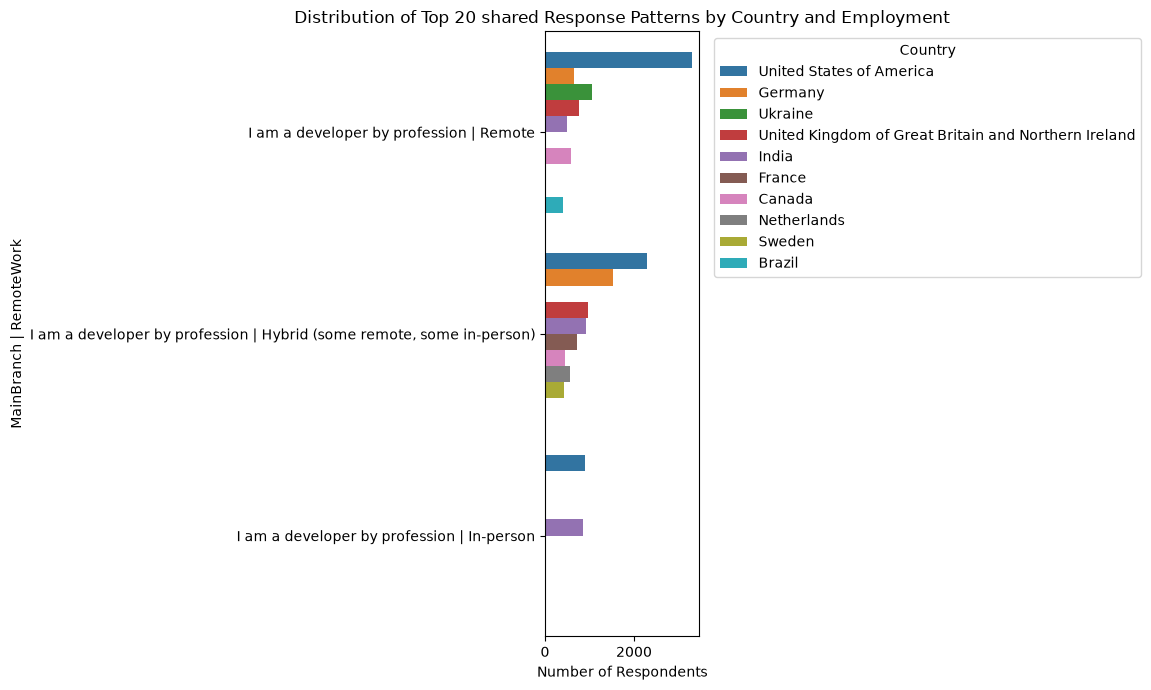

In [66]:
# Overall shared patterns
patterns_counts = (
    df.groupby(
        ["Country"] + pattern_cols,
        dropna=False
    )
    .size()
    .reset_index(name="RespondentCount")
)

# Get the most common 20 patterns for a readable visualization
top_patterns = (
    pattern_counts
    .sort_values("RespondentCount", ascending=False)
    .head(20)
)

# Create a readable label for the pattern
top_patterns["ResponsePattern"] = (
    top_patterns["MainBranch"].fillna("Missing")
    + " | "
    + top_patterns["RemoteWork"].fillna("Missing")
)

# Create the bar chart
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_patterns,
    x="RespondentCount",
    y="ResponsePattern",
    hue="Country"
)

plt.title(
    "Distribution of Top 20 shared Response Patterns by Country and Employment"
)
plt.xlabel("Number of Respondents")
plt.ylabel("MainBranch | RemoteWork")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [67]:
# The ResponseId column is the column defining the record uniqueness
# Verifying if there is duplicates ResponseId
# Number of rows
print("Rows:", len(df))

# Number of unique ResponseIds
print("Unique ResponseIds:", df["ResponseId"].nunique())

# Number of missing ResponseIds
print("Missing ResponseIds:", df["ResponseId"].isna().sum())

# Check for duplicated ResponseIds
print("Duplicated ResponseIds:", df["ResponseId"].duplicated().sum())

Rows: 65457
Unique ResponseIds: 65437
Missing ResponseIds: 0
Duplicated ResponseIds: 20

In [74]:
# Finding duplicated ResponseIds
duplicated_responses = df[
    df["ResponseId"].duplicated(keep=False)
].sort_values("ResponseId")

duplicated_responses

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [75]:
# Check if the duplicated rows are really identical
duplicated_responses.groupby("ResponseId").size()

ResponseId
1        2
2        2
3        2
4        2
5        2
6        2
7        2
8        2
9        2
10       2
9938     2
18522    2
22001    2
35588    2
36796    2
40874    2
44085    2
49767    2
50580    2
51198    2
dtype: int64

In [76]:
# Compare the duplicated rows excluding ResponseId
survey_columns = df.columns.drop("ResponseId")

duplicate_content = (
    duplicated_responses
    .groupby("ResponseId")[survey_columns]
    .nunique(dropna=False)
)

duplicate_content

,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
ResponseId,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
5,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
6,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
7,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
8,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
9,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [77]:
# Removing duplicate rows
df = df.drop_duplicates(subset="ResponseId", keep="first")

print("Rows:", len(df))
print("Unique ResponseIds:", df["ResponseId"].nunique())
print("Duplicated ResponseIds:", df["ResponseId"].duplicated().sum())

Rows: 65437
Unique ResponseIds: 65437
Duplicated ResponseIds: 0

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


**Conclusion:** ResponseId appears to be the intended record identifier, but it is not currently unique in the dataset. 
There are 65,457 rows and 65,437 unique ResponseIds, with 20 duplicated ResponseId occurrences. 
These records were investigated before removed them to determine whether they represent exact duplicate submissions or legitimate repeated/modified responses.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


**Conclusion:** ResponseId was selected as the column for identifying and removing duplicate records because it is the identifier assigned to each survey response. 
The analysis found 65,457 rows but only 65,437 unique ResponseId values, indicating 20 duplicated response records. 
Since multiple respondents can legitimately have identical answers to survey questions such as MainBranch, Employment, and RemoteWork, those columns were not used as duplicate identifiers. Removing records based on these attributes could incorrectly eliminate valid respondents. Therefore, duplicates were removed using ResponseId while retaining the first occurrence of each ID.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
